## Constructor method: path insertion heuristic

This notebook demonstrates the path-only `constructor()` method `method='radial_EW'`.

The method combines two move types:

- endpoint extensions scored by feeder savings
- singleton insertions into internal path edges using the planar embedding

In [1]:
from optiwindnet.importer import load_repository
from optiwindnet.mesh import make_planar_embedding
from optiwindnet.pathfinding import PathFinder
from optiwindnet.heuristics import constructor, NBEW
from optiwindnet.interarraylib import G_from_S, calcload
from optiwindnet.svg import svgplot
from optiwindnet.plotting import gplot

In [2]:
%config InlineBackend.figure_formats = ['svg']
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'
plt.style.use('oled_black')

In [9]:
import sys
import logging

In [10]:
logger = logging.getLogger('optiwindnet.heuristics.constructor')

# WARNING, ERROR, CRITICAL go to stderr
stderr_handler = logging.StreamHandler(sys.stderr)
stderr_handler.setLevel(logging.WARNING)
logger.addHandler(stderr_handler)

# DEBUG, INFO go to stdout (as well as any level below WARNING)
def _log_stdout_filter(record):
    return record.levelno < logging.WARNING

stdout_handler = logging.StreamHandler(sys.stdout)
stdout_handler.addFilter(_log_stdout_filter)
stdout_handler.setLevel(logging.DEBUG)
logger.addHandler(stdout_handler)
logger.setLevel(logging.DEBUG)

In [3]:
locations = load_repository()
selected_handles = (
    'walney2',
    'cazzaro_2022',
    'gode',
    'borkum',
    'horns',
    'london',
)
capacity = 8

In [4]:
for κ in range(4, 10):
    print(f'\nCAPACITY {κ}\n')
    for L in locations:
        P, A = make_planar_embedding(L)
        S = constructor(A, capacity=κ, method='radial_EW')
        Gʹ = G_from_S(S, A)
        print(L.graph['name'], Gʹ.size(weight='length'))


CAPACITY 4

Moray West 101391.56757963712
Borssele 400853.6157477547
Cazzaro-2022G-140 301988.1290480118
Horns Rev 2 110272.55994861886
Borkum Riffgrund 2 70734.03415340057
West of Duddon Sands 146847.50331689883
Horns Rev 3 94400.40499875396
Yi-2019 171140.4752130634
Thanet 83882.7089651593
Race Bank 104000.8074714449
Horns Rev 1 93241.50508265488
Hornsea Two West 313815.6295535617
Rampion 178471.55831447276
Taylor-2023 147727.42069219562
East Anglia ONE 186078.2470278027
Triton Knoll 147094.6791612654
Walney 2 64517.261506807896
Greater Gabbard Inner 158540.95064598296
Cazzaro-2022 12.482908630802124
Borkum Riffgrund 1 82322.61968342244
Anholt 240320.30080746493
Butendiek 93825.19823719883
Gwynt y Mor 162433.279592931
Rødsand 2 107567.15304286333
Sofia 393984.10094541917
Dudgeon 88295.86318573357
Walney 1 48182.41228437711
DanTysk 154835.77988931182
London Array 228525.43196300577
Moray East 182146.9450910728
Dogger Bank A 383439.6707761898
Gode Wind 1 75258.19452882455
Ormonde 2385

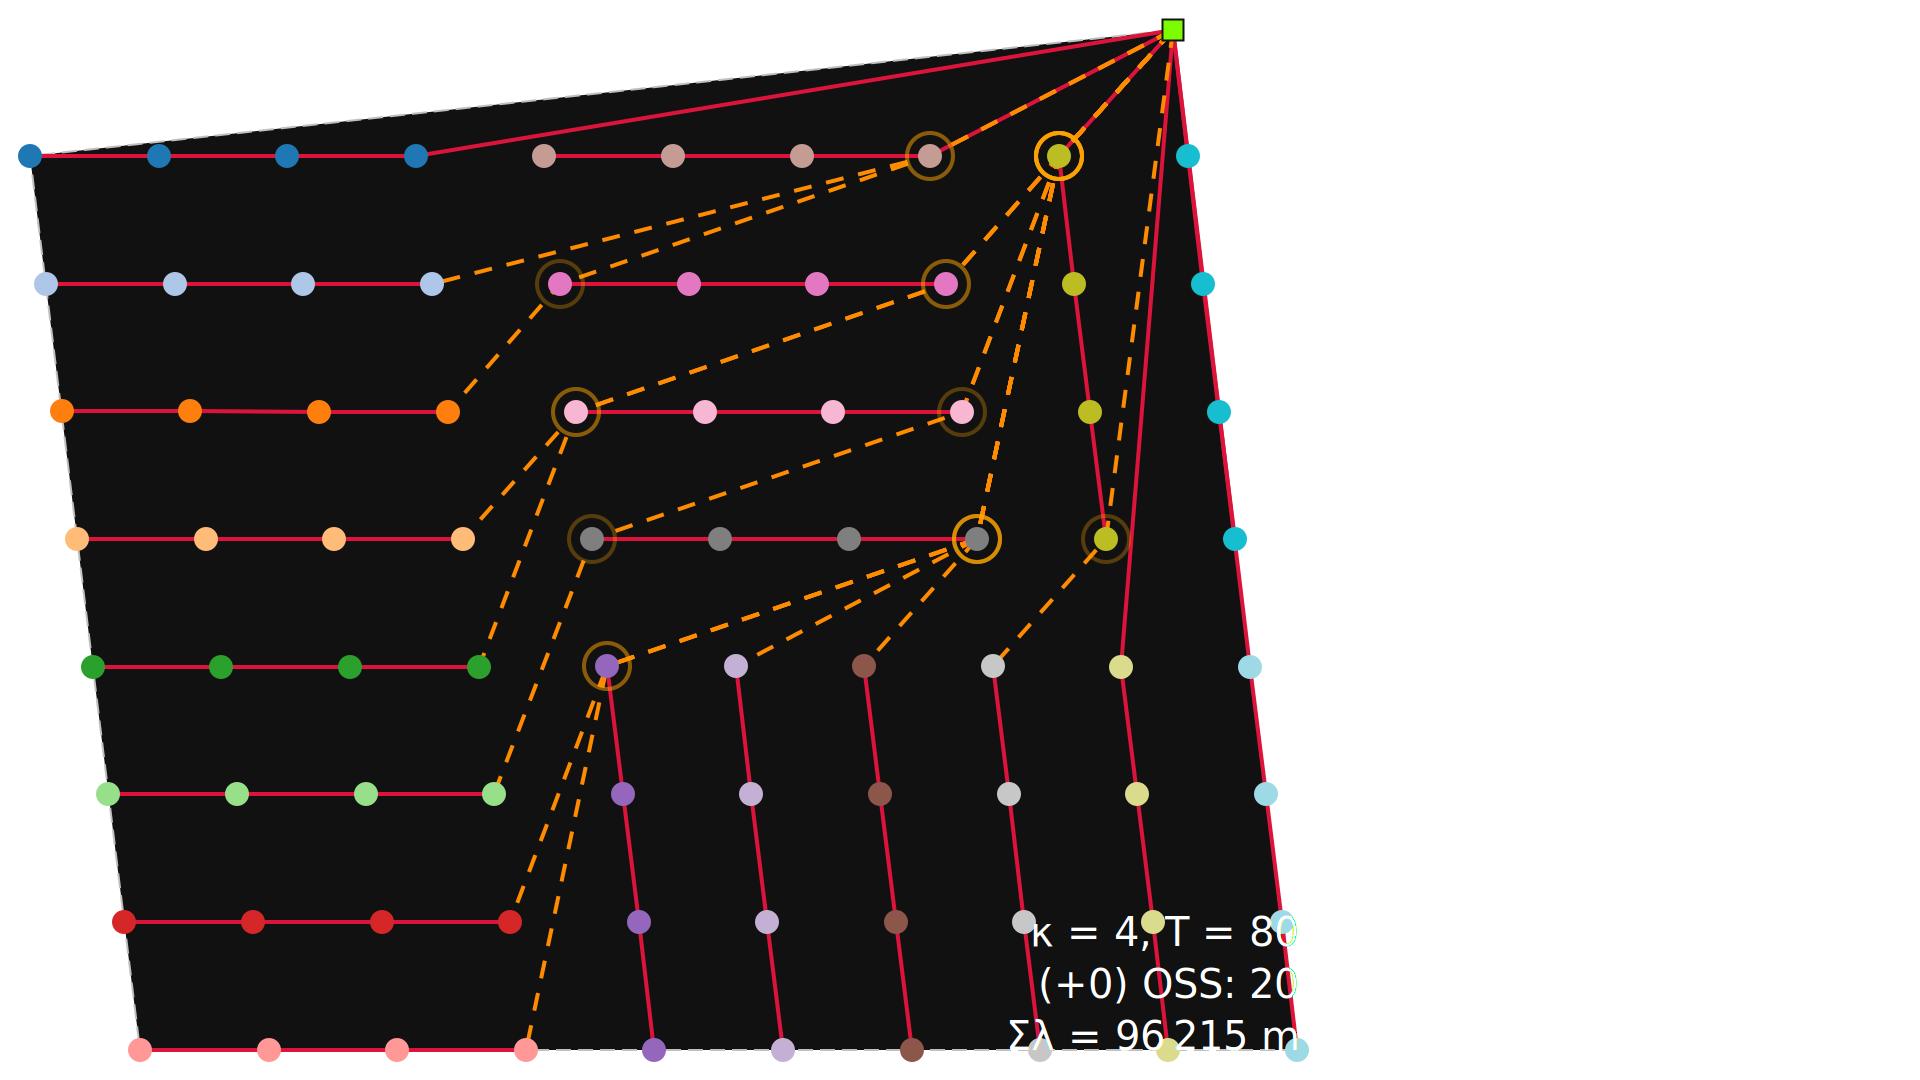

In [4]:
L = locations.horns
P, A = make_planar_embedding(L)
S = constructor(A, capacity=4, method='radial_EW')
Gʹ = G_from_S(S, A)
G = PathFinder(Gʹ, P, A).create_detours()
svgplot(G)

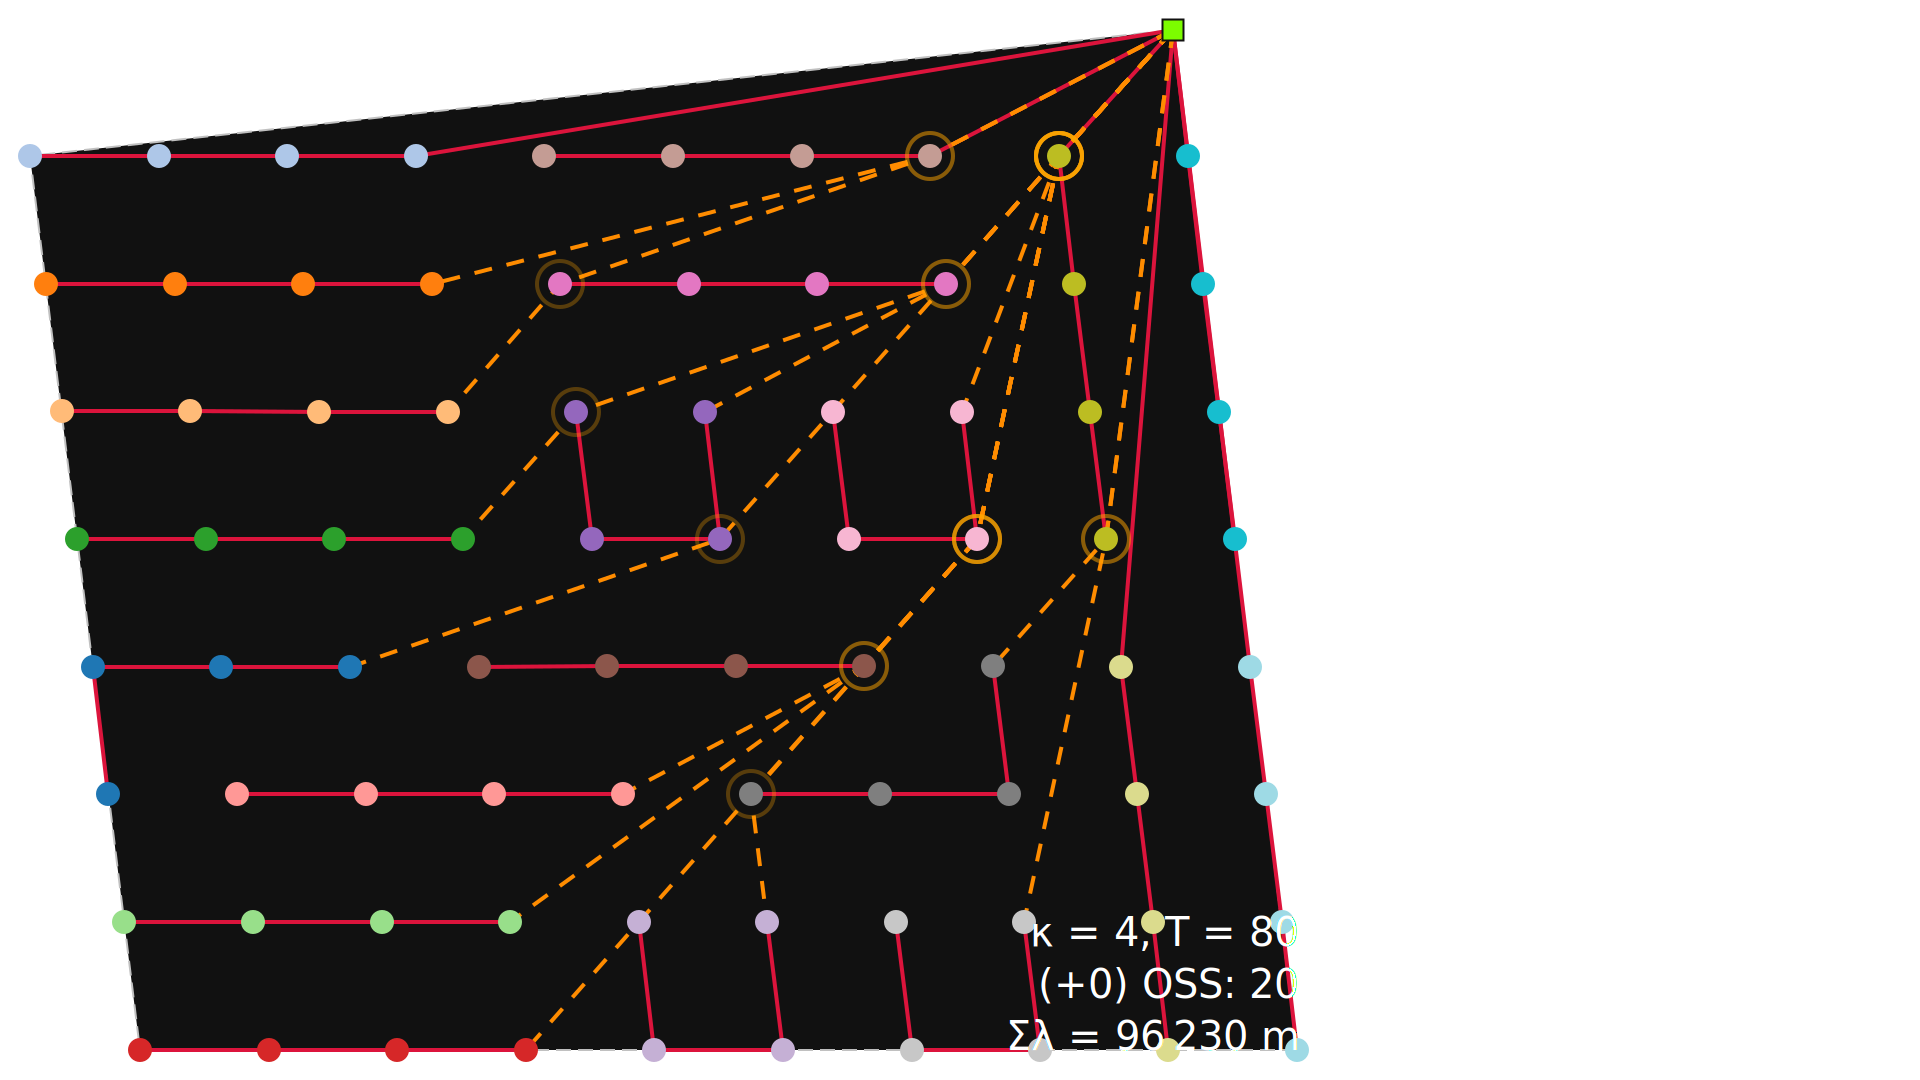

In [7]:
L = locations.horns
P, A = make_planar_embedding(L)
S = constructor(A, capacity=4, method='radial_EW', bias_margin=0.001)
Gʹ = G_from_S(S, A)
G = PathFinder(Gʹ, P, A).create_detours()
svgplot(G)

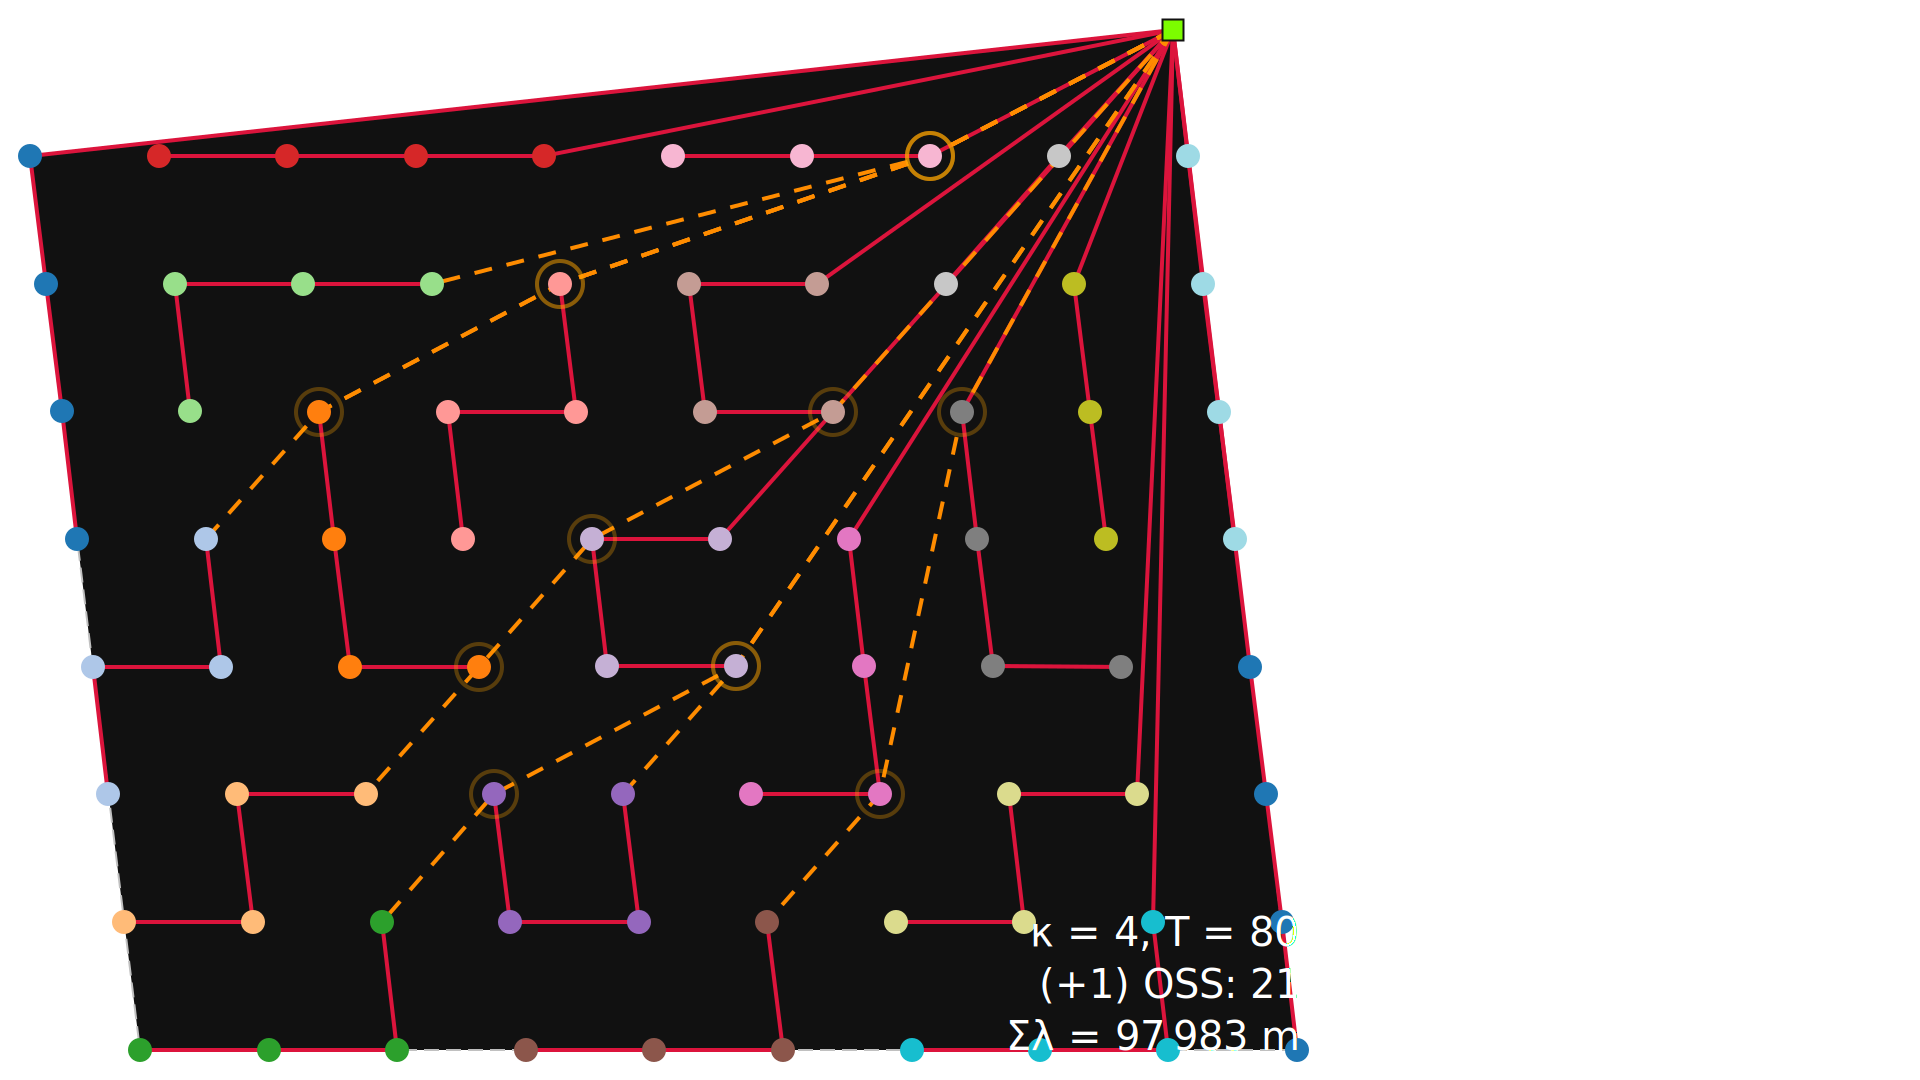

In [9]:
L = locations.horns
P, A = make_planar_embedding(L)
S = constructor(A, capacity=4, method='radial_EW', bias_margin=0.0)
Gʹ = G_from_S(S, A)
G = PathFinder(Gʹ, P, A).create_detours()
svgplot(G)

In [6]:
for κ in range(4, 10):
    print(f'\nCAPACITY {κ}\n')
    for L in locations:
        P, A = make_planar_embedding(L)
        S = constructor(A, capacity=κ, method='radial_EW')
        Gʹ = G_from_S(S, A)
        print(L.graph['name'], Gʹ.size(weight='length'))


CAPACITY 4

Moray West 101391.56757963712
Borssele 401411.2906581469
Cazzaro-2022G-140 299323.7137097516
Horns Rev 2 110272.55994861886
Borkum Riffgrund 2 70734.03415340057
West of Duddon Sands 147089.724252882
Horns Rev 3 93938.31328939693
Yi-2019 171249.78549518625
Thanet 83341.25671891206
Race Bank 104031.47885868786
Horns Rev 1 97633.47472983199
Hornsea Two West 313670.08686717
Rampion 175738.04899061727
Taylor-2023 149412.45080068204
East Anglia ONE 185812.34768638547
Triton Knoll 145295.5832559846
Walney 2 64517.261506807896
Greater Gabbard Inner 158921.09117880766
Cazzaro-2022 12.413706730506375
Borkum Riffgrund 1 83690.26460468069
Anholt 240320.30080746493
Butendiek 94584.50949852308
Gwynt y Mor 164788.35479204115
Rødsand 2 106897.01971371412
Sofia 391856.151739821
Dudgeon 88070.39018172807
Walney 1 48362.47950813369
DanTysk 154746.79276508768
London Array 230300.8592548841
Moray East 184307.88993066287
Dogger Bank A 381027.15210453817
Gode Wind 1 76425.43956813915
Ormonde 238

In [26]:
L = locations.wikinger
P, A = make_planar_embedding(L)

In [27]:
S = constructor(A, capacity=capacity, method='radial_EW')

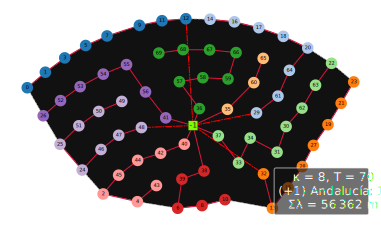

In [30]:
Gʹ = G_from_S(S, A)
gplot(Gʹ, node_tag=True);

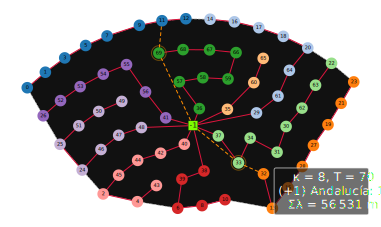

In [31]:
G = PathFinder(Gʹ, P, A).create_detours()
gplot(G, node_tag=True);

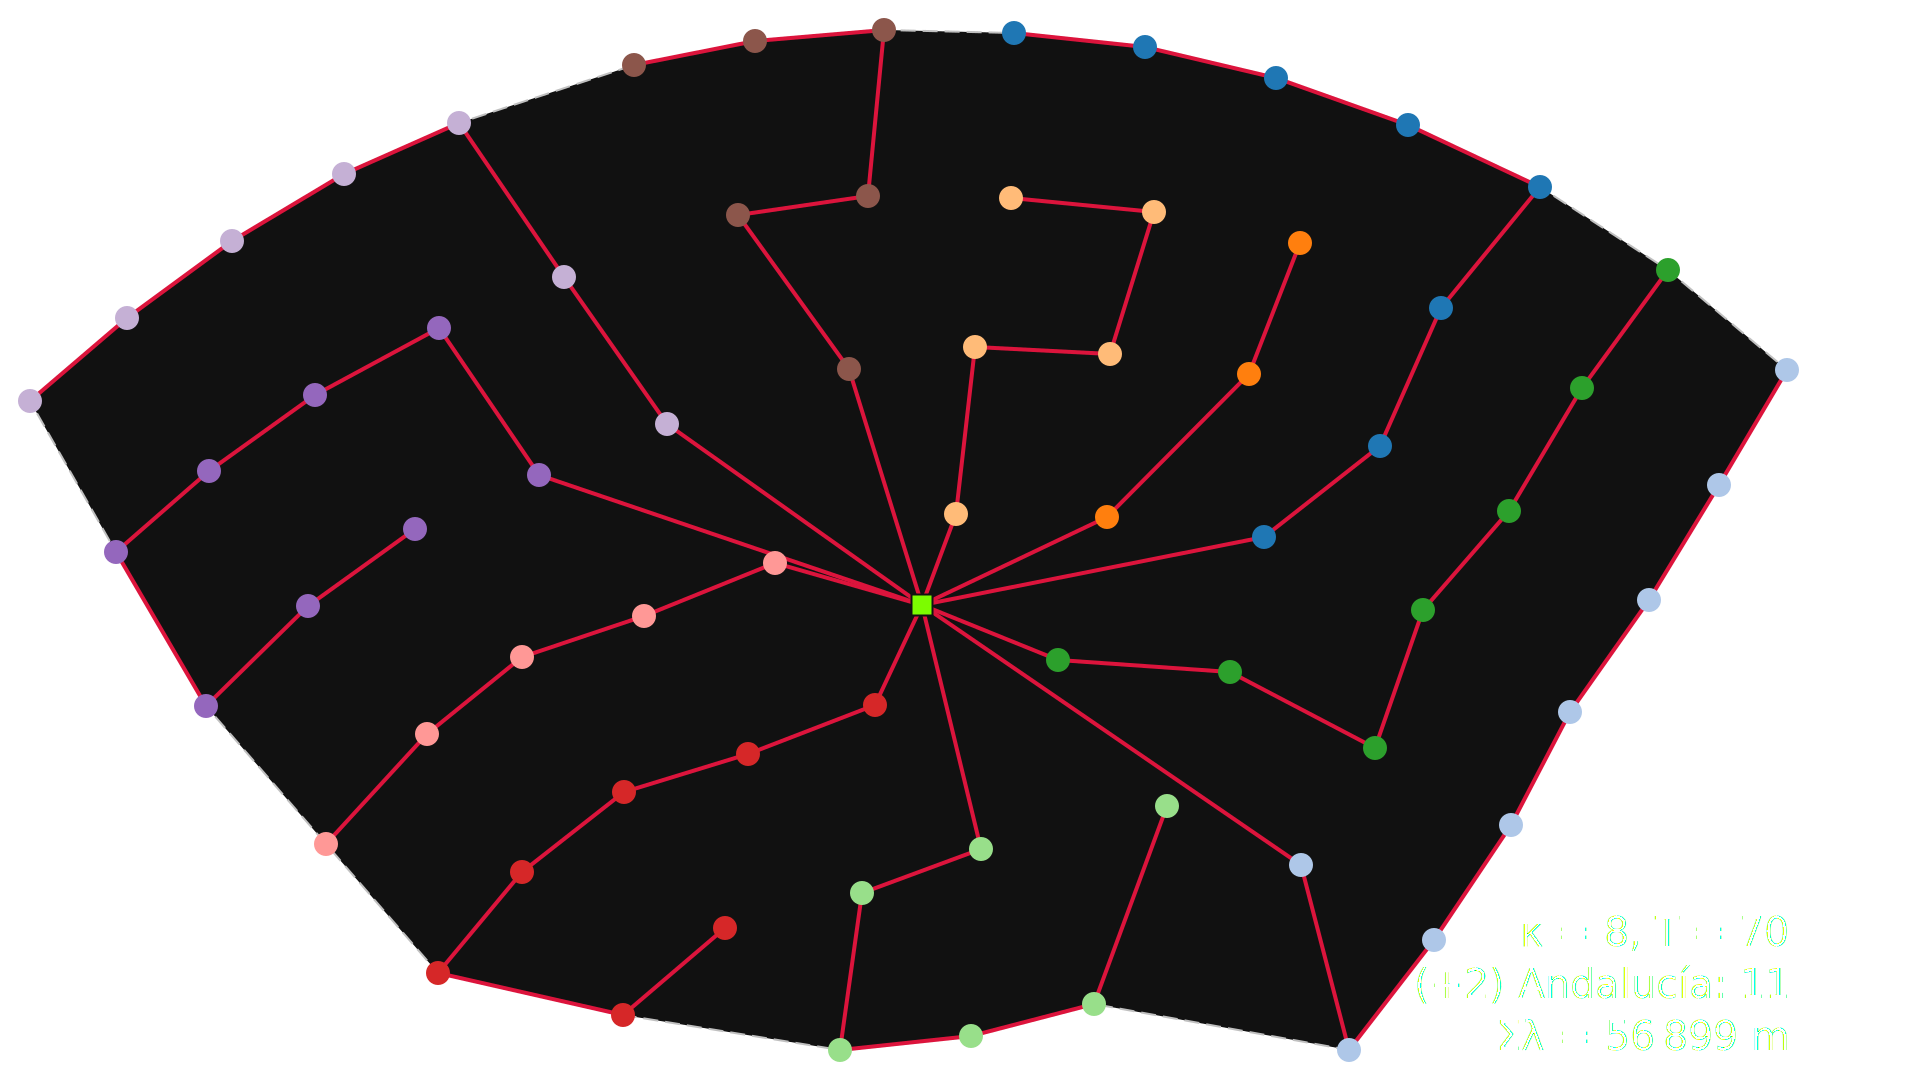

In [24]:
Gnbew = NBEW(locations.wikinger, 8)
calcload(Gnbew)
svgplot(Gnbew)

In [7]:
L = locations.walney2
P, A = make_planar_embedding(L)

In [8]:
S = constructor(A, capacity=capacity, method='radial_EW')

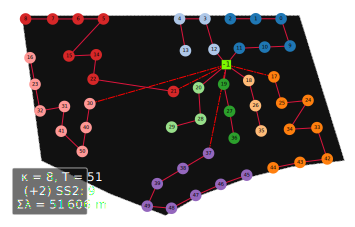

In [9]:
Gʹ = G_from_S(S, A)
gplot(Gʹ, node_tag=True);

In [10]:
L = locations.cazzaro_2022
P, A = make_planar_embedding(L)

In [11]:
S = constructor(A, capacity=capacity, method='radial_EW')

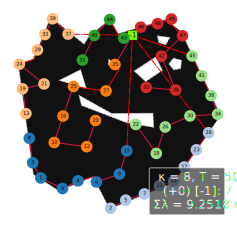

In [12]:
Gʹ = G_from_S(S, A)
gplot(Gʹ, node_tag=True);

In [13]:
L = locations.gode
P, A = make_planar_embedding(L)

In [14]:
S = constructor(A, capacity=capacity, method='radial_EW')

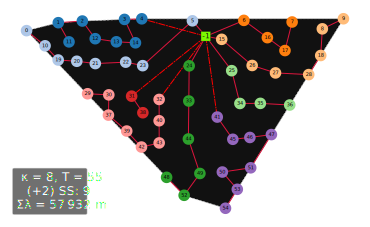

In [15]:
Gʹ = G_from_S(S, A)
gplot(Gʹ, node_tag=True);

In [16]:
L = locations.borkum
P, A = make_planar_embedding(L)

In [17]:
S = constructor(A, capacity=capacity, method='radial_EW')

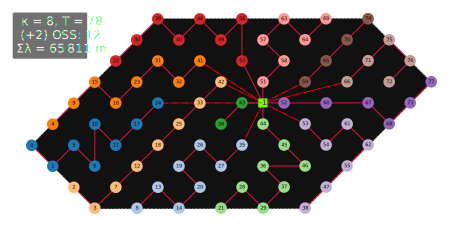

In [18]:
Gʹ = G_from_S(S, A)
gplot(Gʹ, node_tag=True);

In [8]:
L = locations.london
P, A = make_planar_embedding(L)

In [11]:
S = constructor(A, capacity=capacity, method='radial_EW')

In [13]:
S = constructor(A, capacity=capacity, method='radial_EW', bias_margin=0.0)

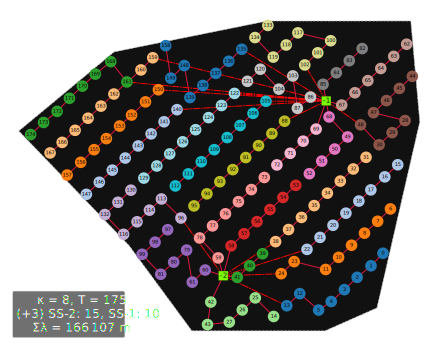

In [14]:
Gʹ = G_from_S(S, A)
gplot(Gʹ, node_tag=True, figsize=(6, 5));

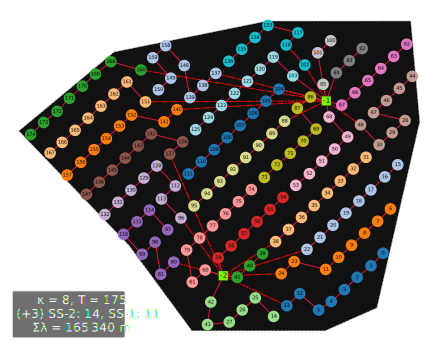

In [12]:
Gʹ = G_from_S(S, A)
gplot(Gʹ, node_tag=True, figsize=(6, 5));

In [19]:
L = locations.london
P, A = make_planar_embedding(L)

In [20]:
S = constructor(A, capacity=capacity, method='radial_EW')

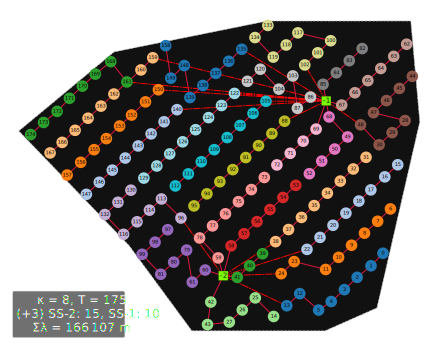

In [21]:
Gʹ = G_from_S(S, A)
gplot(Gʹ, node_tag=True, figsize=(6, 5));

[{'handle': 'walney2',
  'T': 51,
  'R': 1,
  'edges': 51,
  'feeders': 9,
  'iterations': 46,
  'max_load': 8},
 {'handle': 'cazzaro_2022',
  'T': 50,
  'R': 1,
  'edges': 50,
  'feeders': 7,
  'iterations': 46,
  'max_load': 8},
 {'handle': 'gode',
  'T': 55,
  'R': 1,
  'edges': 55,
  'feeders': 9,
  'iterations': 55,
  'max_load': 8},
 {'handle': 'borkum',
  'T': 78,
  'R': 1,
  'edges': 78,
  'feeders': 12,
  'iterations': 77,
  'max_load': 8},
 {'handle': 'horns',
  'T': 80,
  'R': 1,
  'edges': 80,
  'feeders': 11,
  'iterations': 74,
  'max_load': 8},
 {'handle': 'london',
  'T': 175,
  'R': 2,
  'edges': 175,
  'feeders': 25,
  'iterations': 176,
  'max_load': 8}]

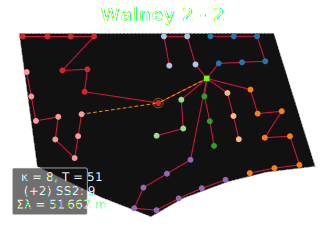

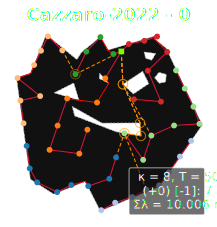

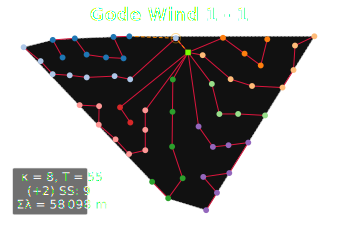

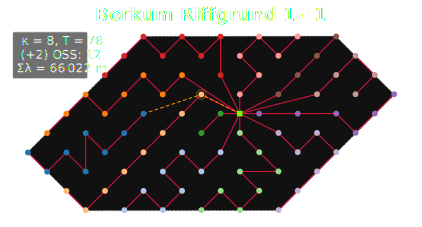

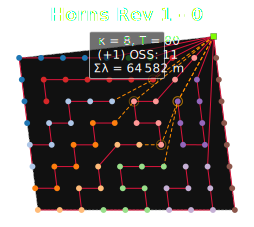

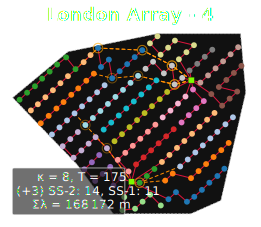

In [22]:
results = []
graphs = {}

for handle in selected_handles:
    L = getattr(locations, handle)
    P, A = make_planar_embedding(L)
    S = constructor(A, capacity=capacity, method='radial_EW')
    Gʹ = G_from_S(S, A)
    G = PathFinder(Gʹ, P, A).create_detours()
    ax = gplot(G)
    ax.set_title(f"{G.graph['name']} - {G.graph['num_insertions']}")
    graphs[handle] = G
    results.append(
        {
            'handle': handle,
            'T': L.graph['T'],
            'R': L.graph['R'],
            'edges': S.number_of_edges(),
            'feeders': sum(S.degree(root) for root in range(-L.graph['R'], 0)),
            'iterations': S.graph['iterations'],
            'max_load': S.graph['max_load'],
        }
    )

results

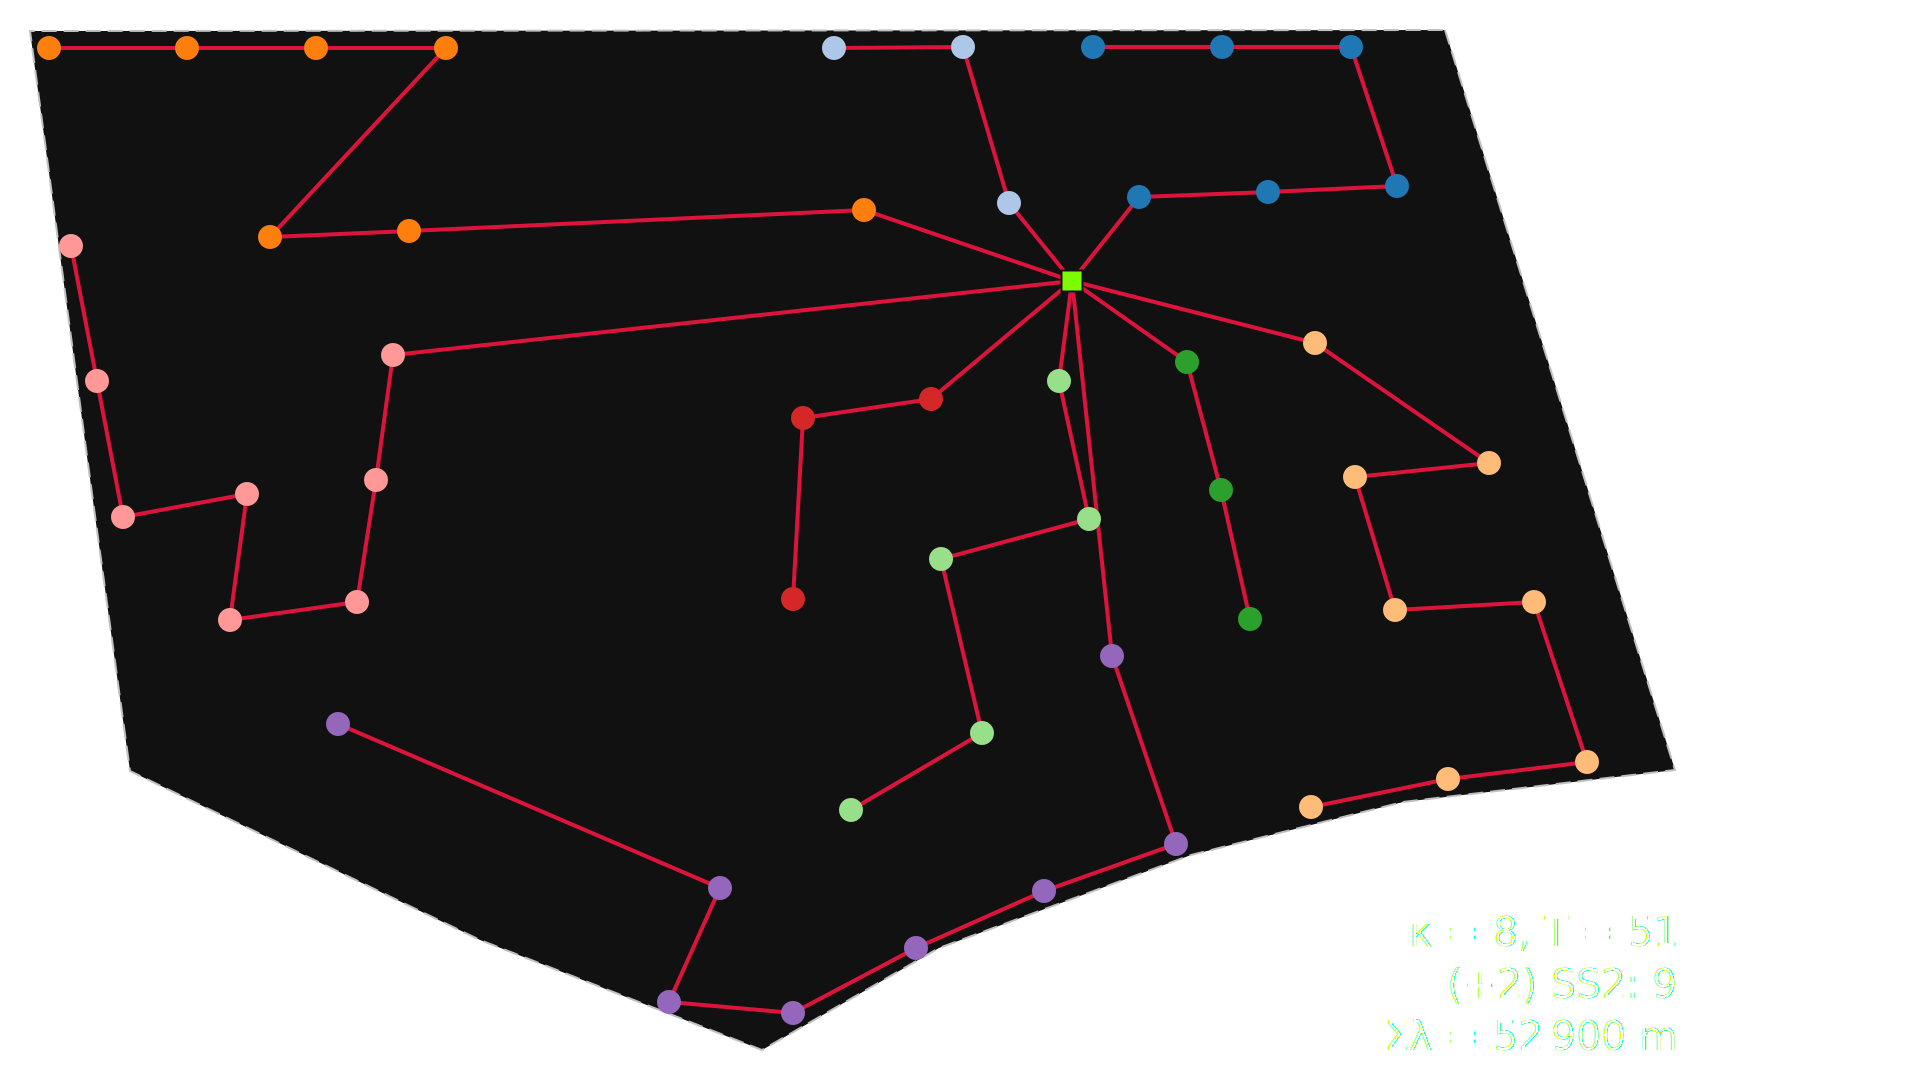

In [23]:
Gnbew = NBEW(locations.walney2, 8)
calcload(Gnbew)
svgplot(Gnbew)

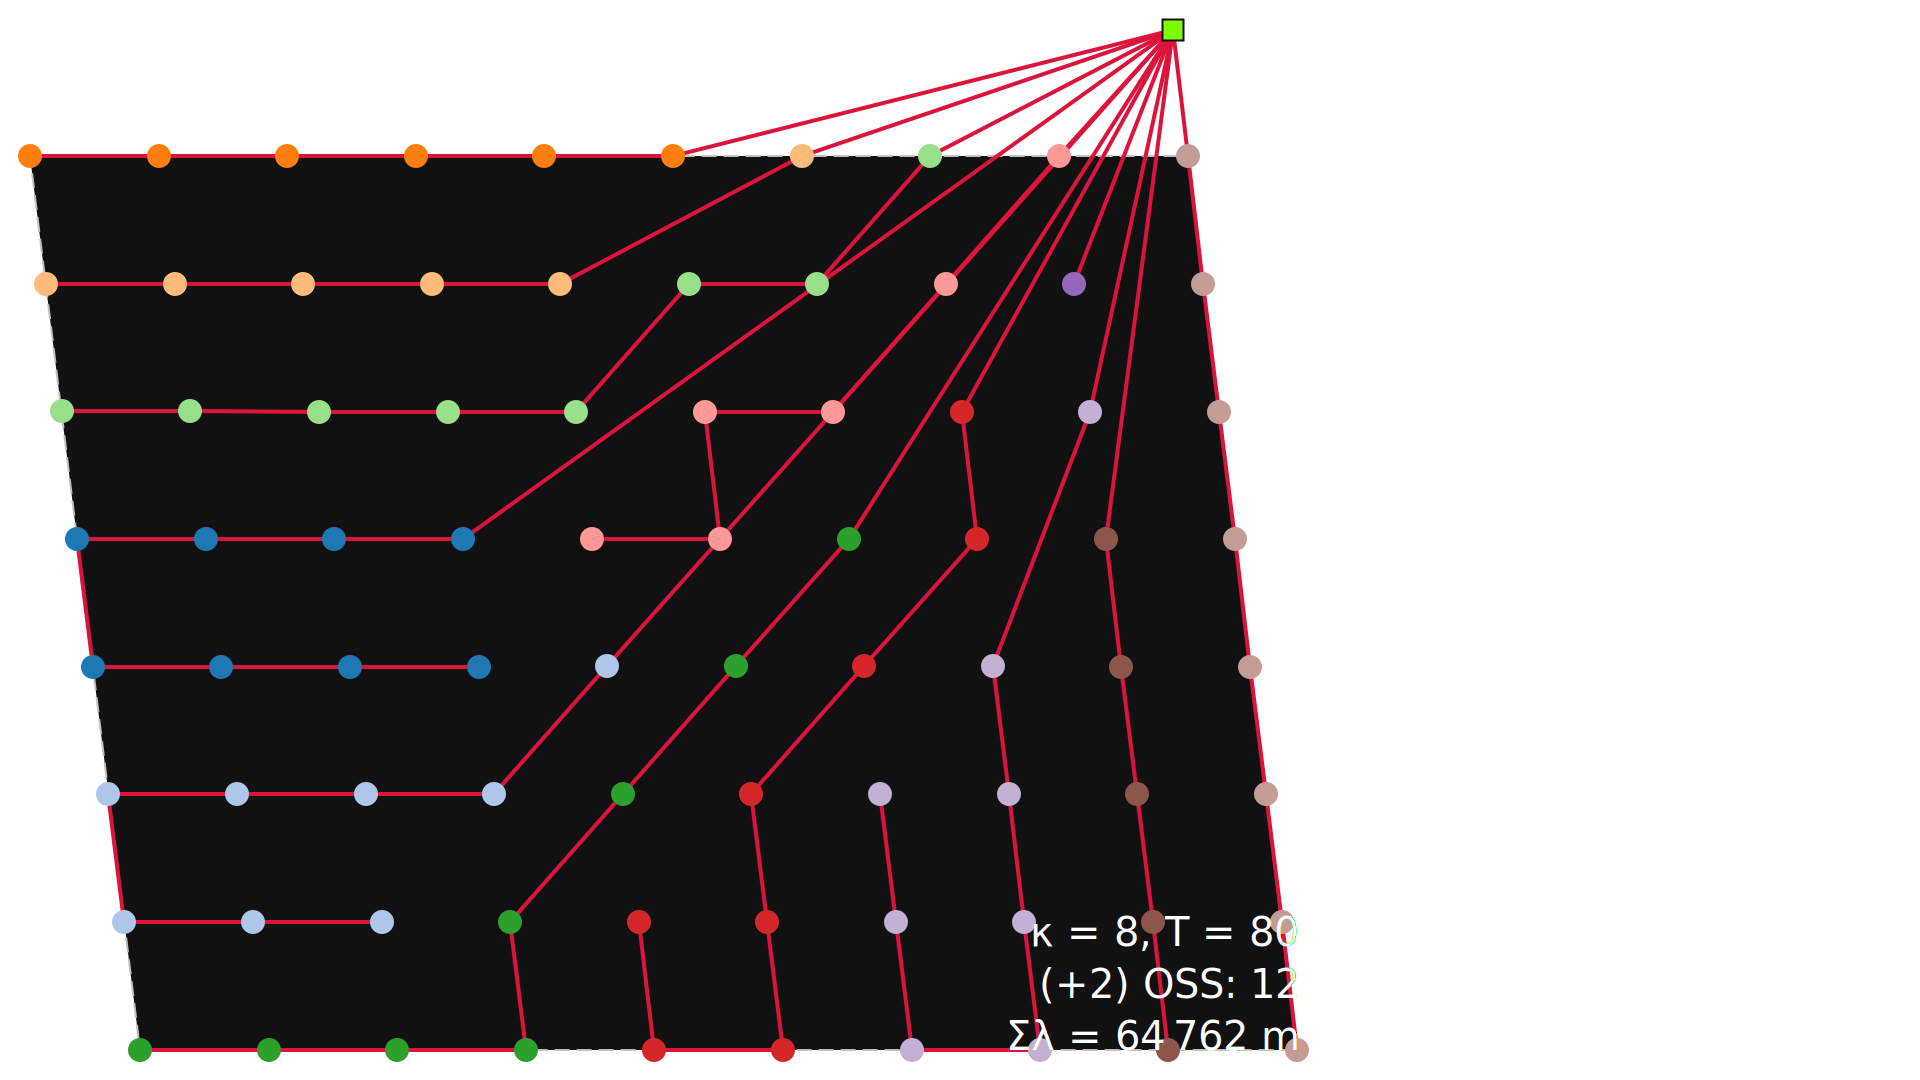

In [9]:
Gnbew = NBEW(locations.horns, 8)
calcload(Gnbew)
svgplot(Gnbew)

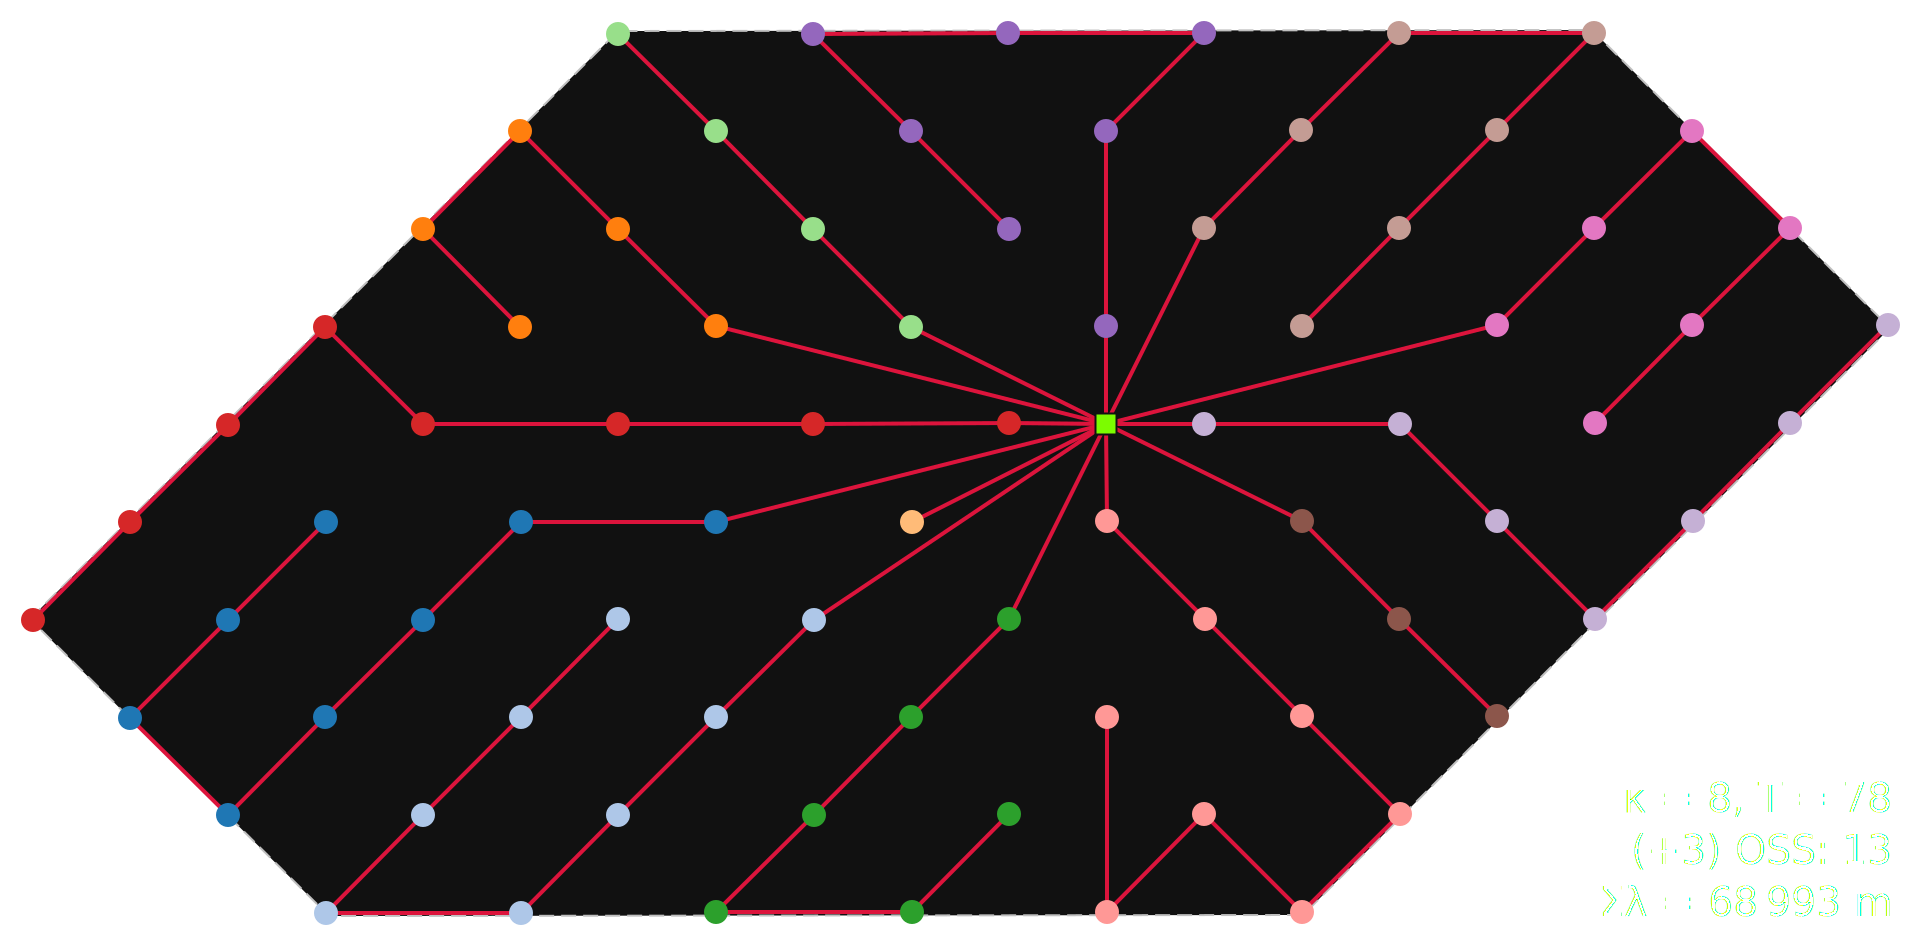

In [5]:
Gnbew = NBEW(locations.borkum, 8)
calcload(Gnbew)
svgplot(Gnbew)

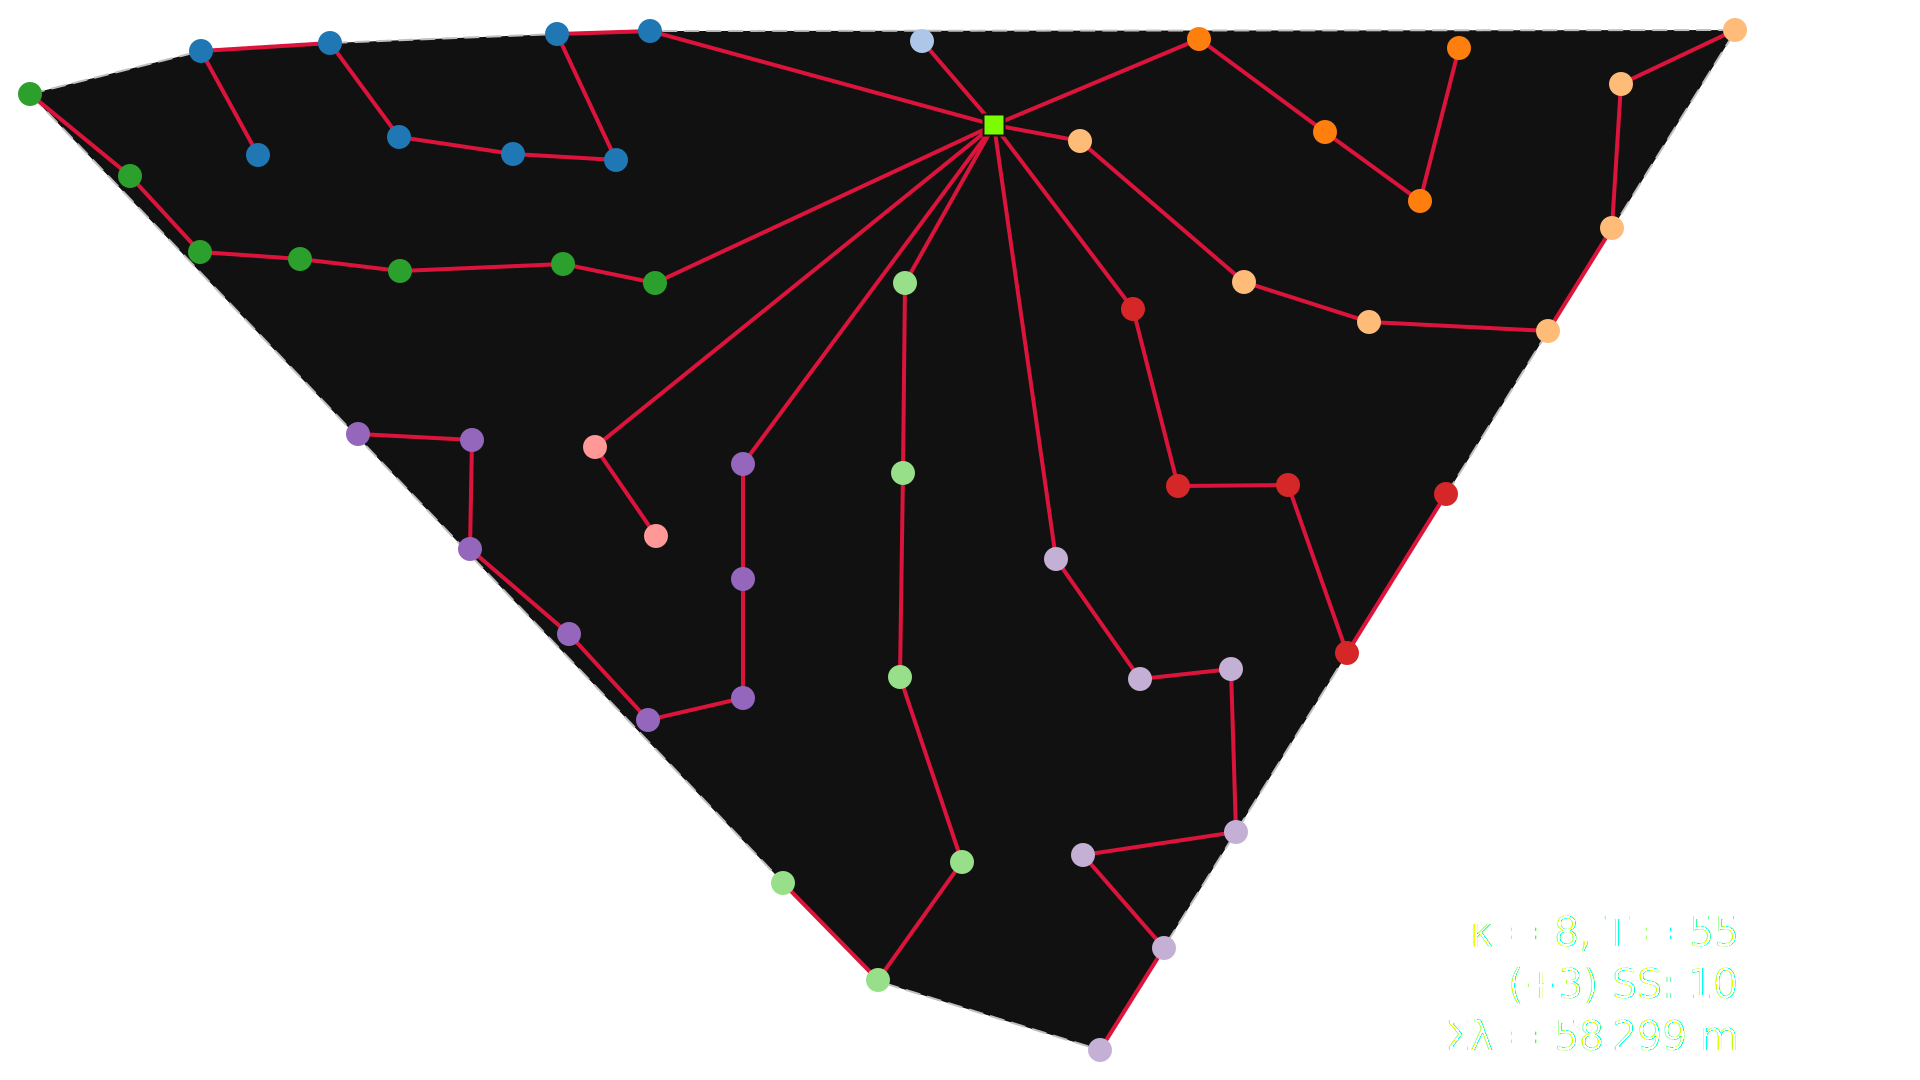

In [6]:
Gnbew = NBEW(locations.gode, 8)
calcload(Gnbew)
svgplot(Gnbew)

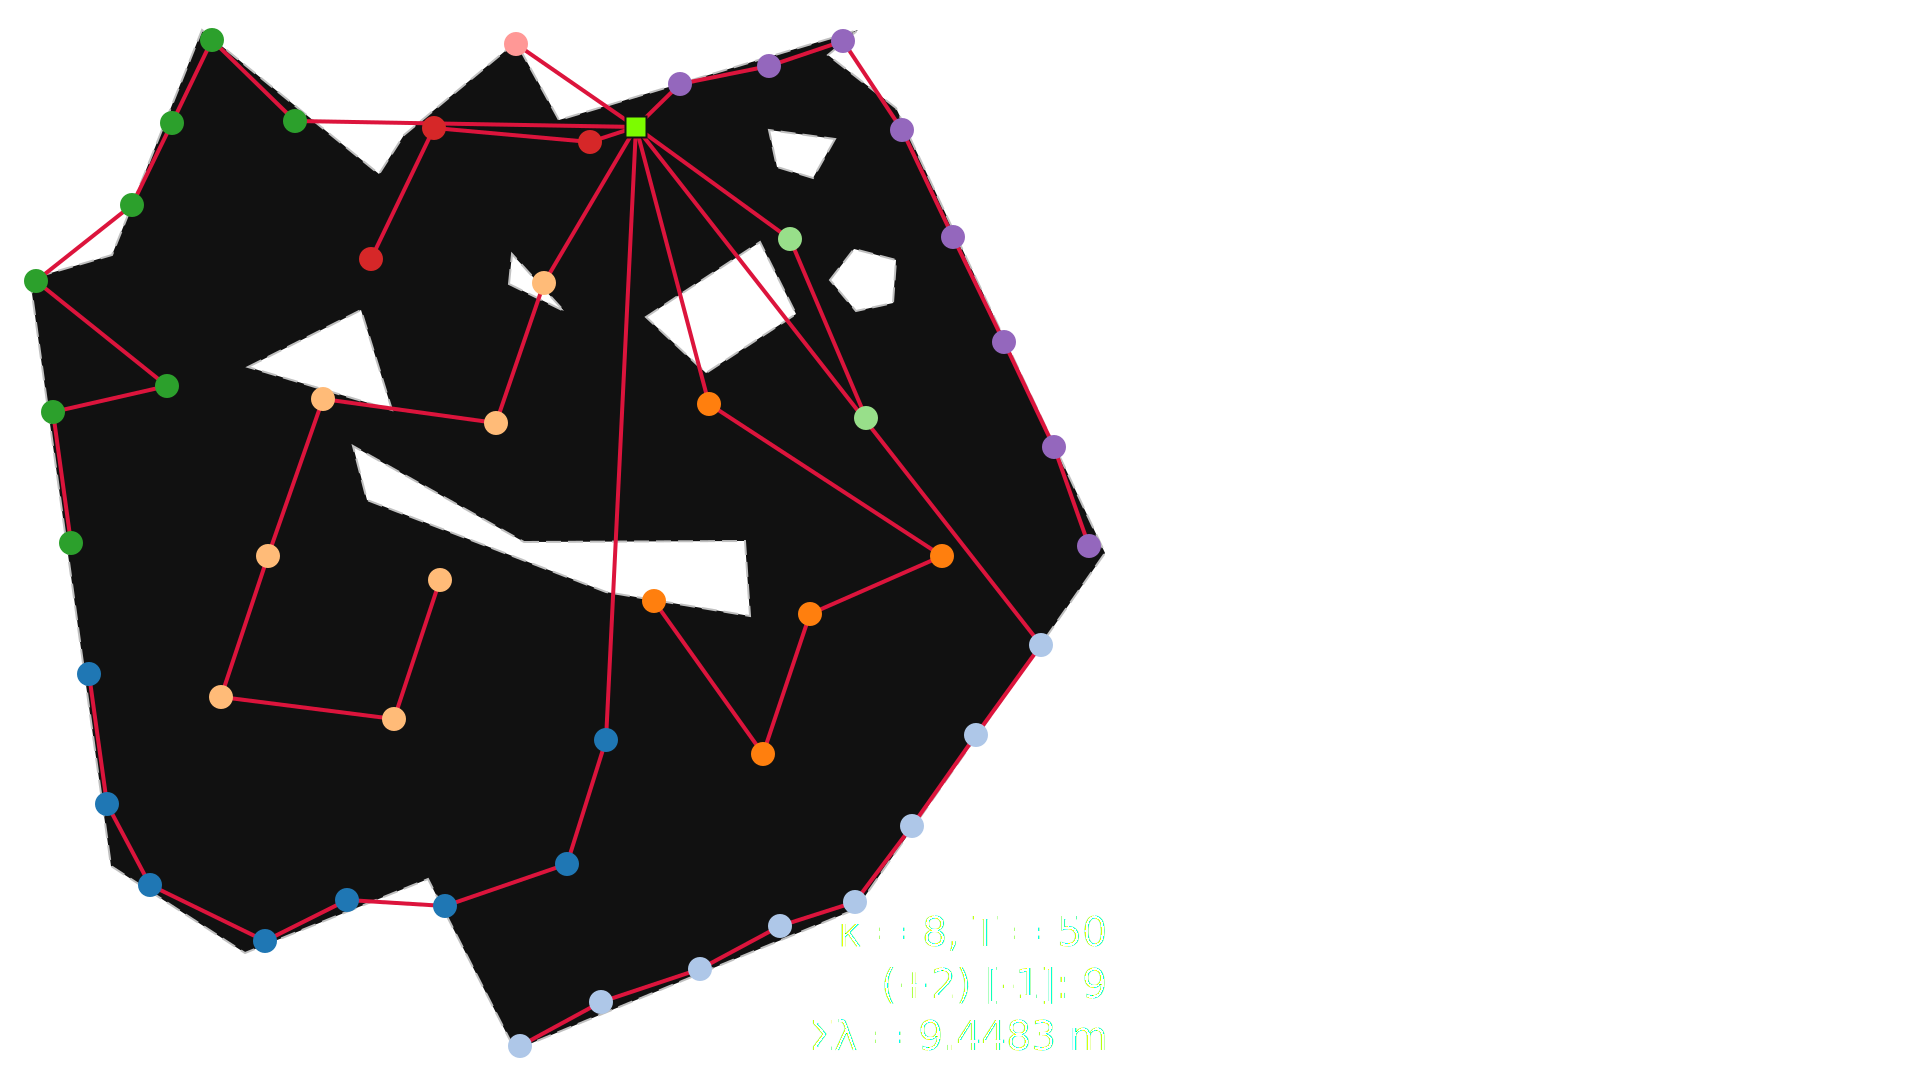

In [7]:
Gnbew = NBEW(locations.cazzaro_2022, 8)
calcload(Gnbew)
svgplot(Gnbew)

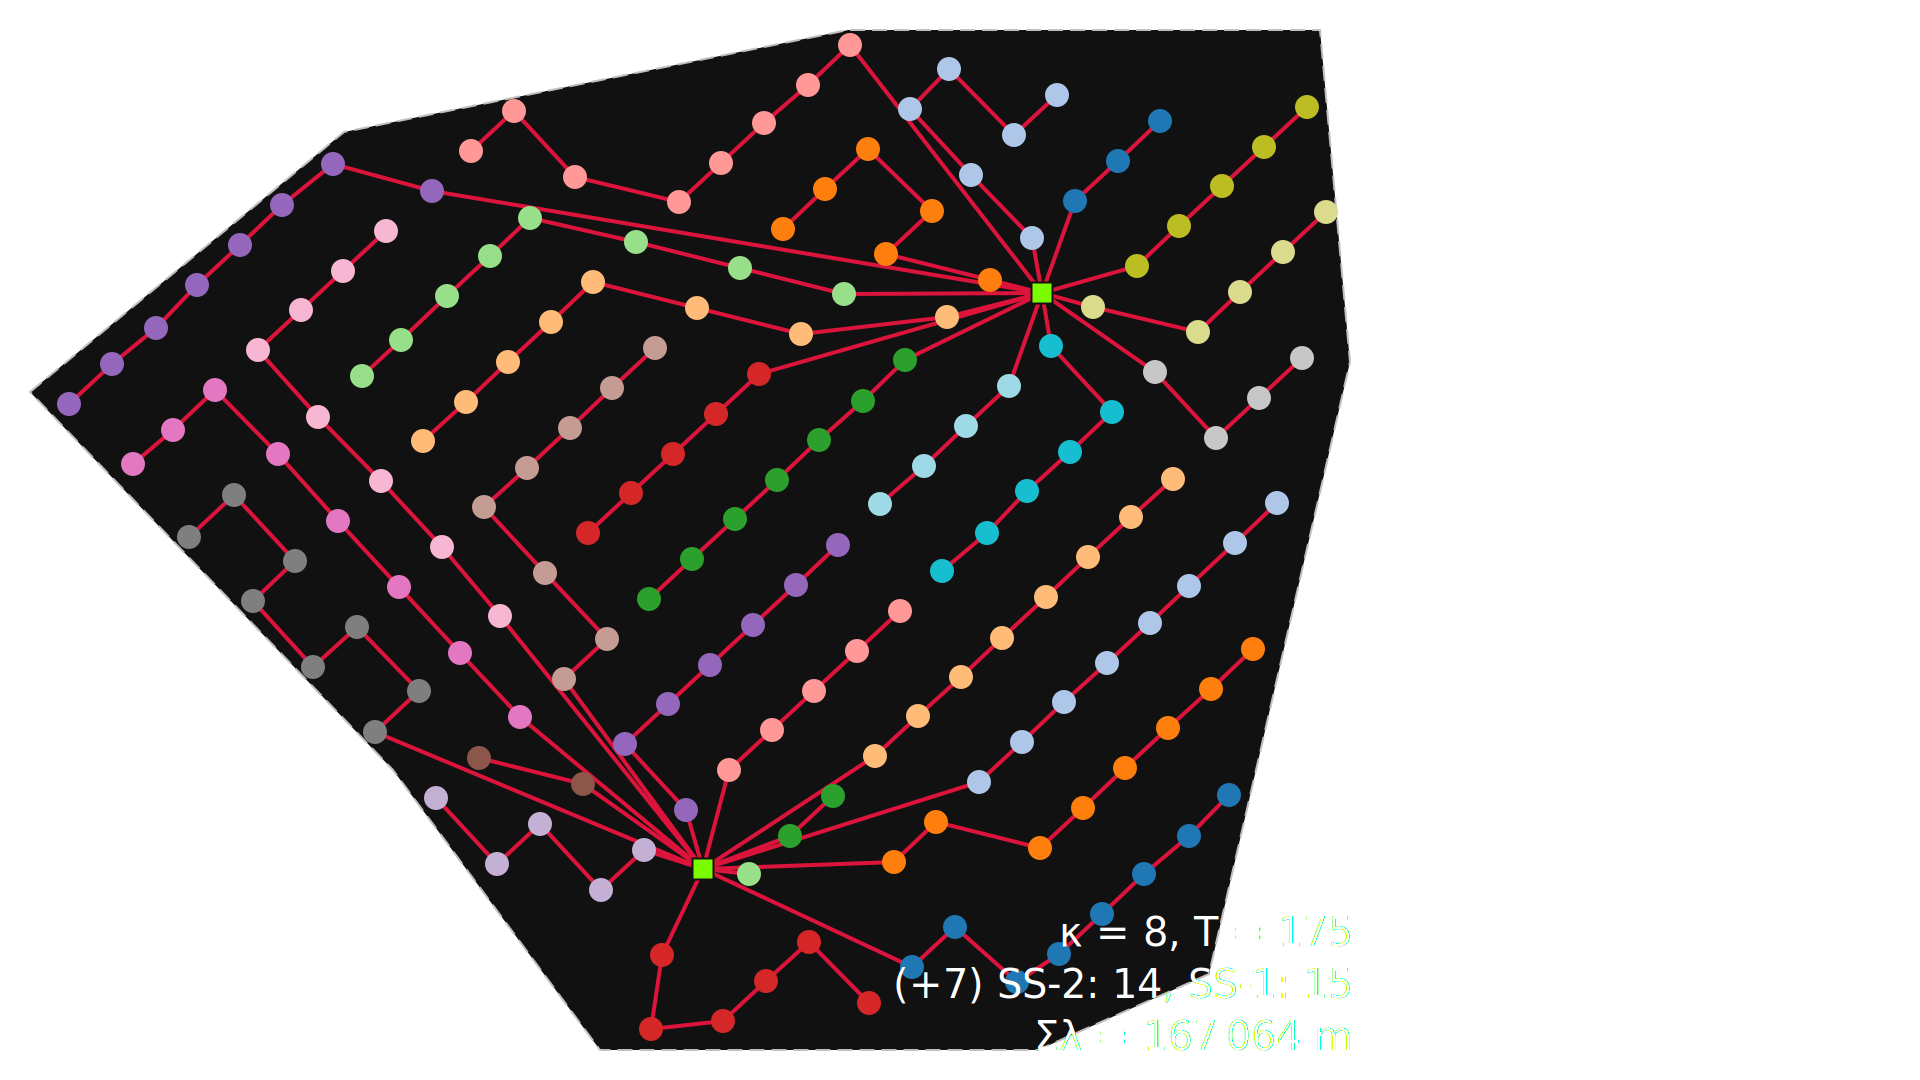

In [6]:
Gnbew = NBEW(locations.london, 8)
calcload(Gnbew)
svgplot(Gnbew)

### Plot one of the repository examples

In [ ]:
svgplot(graphs['cazzaro_2022'])

### Multi-root example

In [ ]:
L_multi = locations.cazzaro_2022G140
_, A_multi = make_planar_embedding(L_multi)
S_multi = constructor(A_multi, capacity=capacity, method='radial_EW')
G_multi = G_from_S(S_multi, A_multi)
{
    'handle': L_multi.graph['handle'],
    'T': L_multi.graph['T'],
    'R': L_multi.graph['R'],
    'edges': S_multi.number_of_edges(),
    'feeders': sum(S_multi.degree(root) for root in range(-L_multi.graph['R'], 0)),
    'iterations': S_multi.graph['iterations'],
    'max_load': S_multi.graph['max_load'],
}

In [ ]:
svgplot(G_multi)